In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.duplicated('id').any()

np.False_

In [5]:
df.columns = ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke']

In [6]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
df['age'] = df['age'].astype('int')

In [8]:
df['work_type'] = df['work_type'].replace({'Never_worked': 'Unemployed','children': 'Unemployed'})

In [9]:
df['work_type'] = df['work_type'].str.title()

In [10]:
df['work_type'] = df['work_type'].str.replace('_', ' ')
df['work_type'] = df['work_type'].str.replace('-', ' ')

In [11]:
bmi_mean = df['bmi'].mean().round(2)
df['bmi'] = df['bmi'].fillna(bmi_mean)

In [12]:
df['smoking_status'] = df['smoking_status'].str.title()

In [13]:
df = df[df['gender']!='Other']

In [14]:
df['age_grp'] = pd.cut(df['age'], bins=[0,10,18,30,50,100], labels=['Kid','Teen','Adult','Middle Aged','Oldage'], right=True, include_lowest=True)

In [15]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_grp
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.60,Formerly Smoked,1,Oldage
1,51676,Female,61,0,0,Yes,Self Employed,Rural,202.21,28.89,Never Smoked,1,Oldage
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.50,Never Smoked,1,Oldage
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.40,Smokes,1,Middle Aged
4,1665,Female,79,1,0,Yes,Self Employed,Rural,174.12,24.00,Never Smoked,1,Oldage


In [16]:
gen_cnt = df['gender'].value_counts()

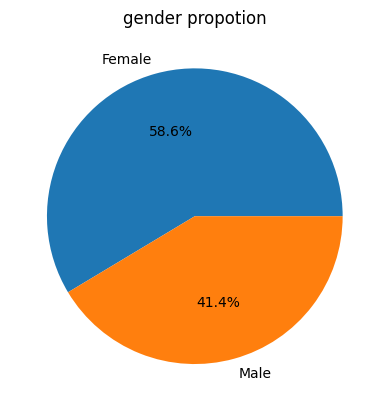

In [39]:
plt.pie(x=gen_cnt.values, labels=gen_cnt.index, autopct='%.1f%%')
plt.title('gender propotion')
plt.show()

females has the majority in this dataset compared to male 

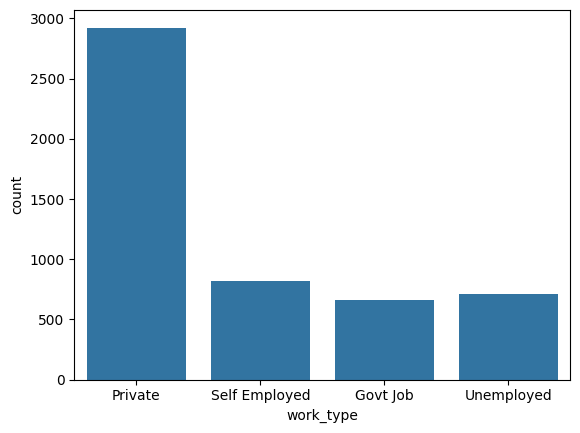

In [ ]:
sns.countplot(df, x='work_type')
plt.title('count of work type')
plt.show()

most of the people are having private work

<Figure size 2000x500 with 0 Axes>

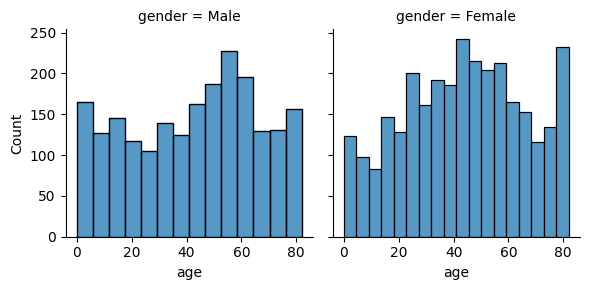

In [19]:
plt.figure(figsize=(20,5))
fd = sns.FacetGrid(df, col='gender')
fd.map(sns.histplot, 'age')
plt.tight_layout()
plt.show()

majority of the male patients are in the age category of 47-60 as of for females the commong age group is 40-60

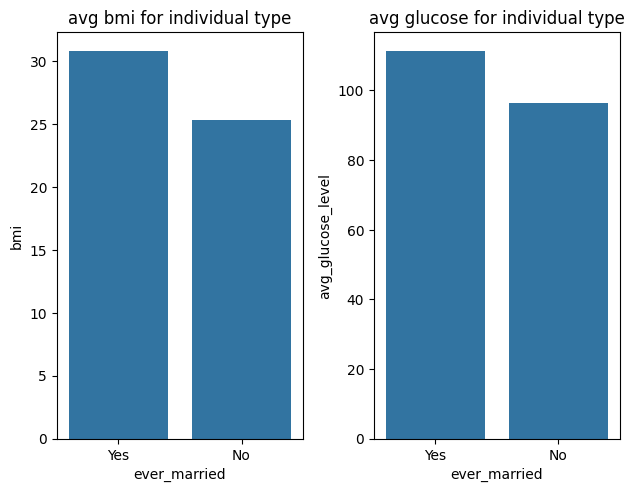

In [40]:
f, a = plt.subplots(ncols=2)
sns.barplot(df, x='ever_married', y='bmi', errorbar=None, ax=a[0])
sns.barplot(df, x='ever_married', y='avg_glucose_level', errorbar=None, ax=a[1])
plt.tight_layout()
a[0].set_title('avg bmi for individual type')
a[1].set_title('avg glucose for individual type')
plt.show()

peopel who are married is having higher avg bmi level and higher avg glucose level compared to unmarried

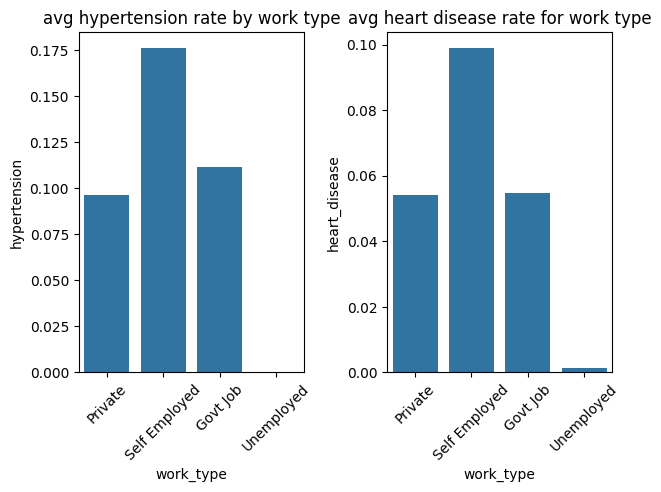

In [42]:
f, a = plt.subplots(ncols=2)
sns.barplot(df, x='work_type', y='hypertension', errorbar=None, ax=a[0])
a[0].set_xticks(ticks=df['work_type'].unique(), labels= df['work_type'].unique(), rotation=45)
sns.barplot(df, x='work_type', y='heart_disease', errorbar=None, ax=a[1])
a[1].set_xticks(ticks=df['work_type'].unique(), labels= df['work_type'].unique(), rotation=45)
plt.tight_layout()
a[0].set_title('avg hypertension rate by work type')
a[1].set_title('avg heart disease rate for work type')
plt.show()

self employed people are likley to hypertension and heart disease compared to others

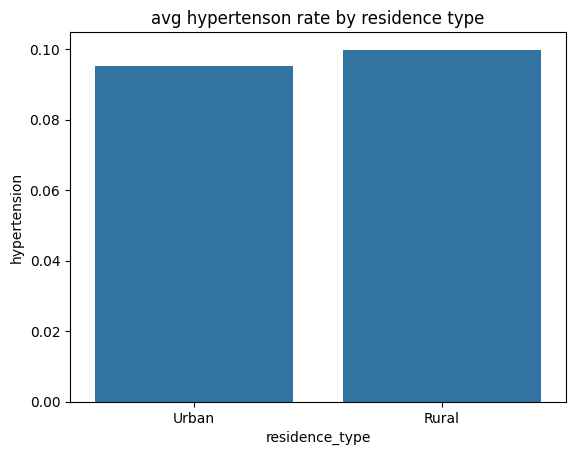

In [43]:
sns.barplot(df, x='residence_type', y='hypertension', errorbar=None)
plt.title('avg hypertenson rate by residence type')
plt.show()

people residing in rural area is likeley to have hypertension

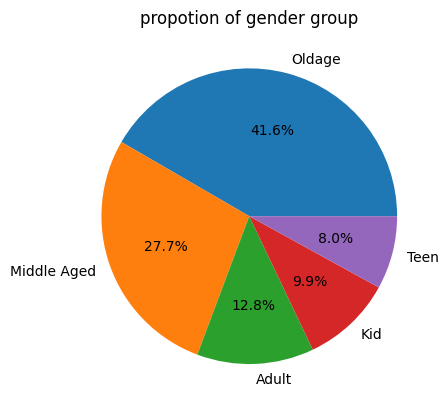

In [44]:
grp_cnt = df['age_grp'].value_counts()
plt.pie(x=grp_cnt.values, labels=grp_cnt.index, autopct='%.1f%%')
plt.title('propotion of gender group')
plt.show()

most of the people are in their oldage followed by middle aged, adults and so on

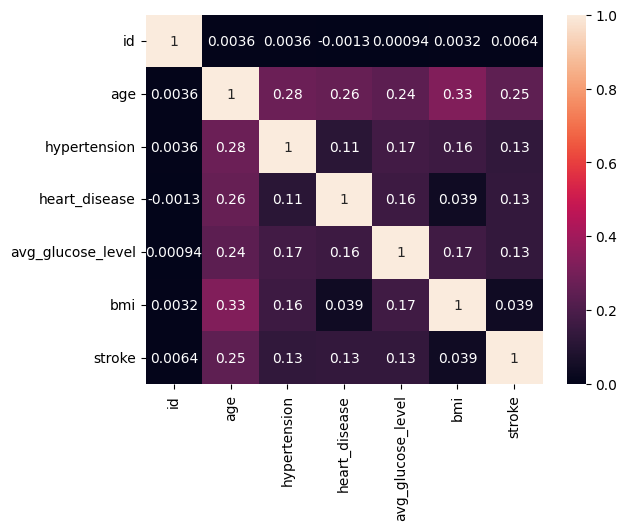

In [24]:
cr = df.corr(numeric_only=True)
sns.heatmap(cr, annot=True)
plt.show()

age has a significant affect on having issues like hypertension, heart issues, rise in glucose level showing possibility of diabetese, body fat % increase and stroke

these are in a moderate positive relation with age

increase in bmi can increse the chance of having hypertension, diabetese, this is a weak positive relation

increase in glucose level incrases hypertension

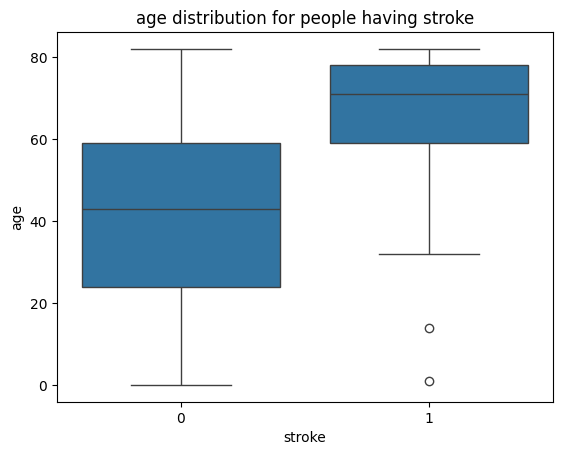

In [45]:
sns.boxplot(df, x='stroke', y='age')
plt.title('age distribution for people having stroke')
plt.show()

people having storke are mostly from the age category of 60-77 in which the median age is ~73 very few people have stroke above the age of 77-82 there are more people having stroke below the age of 60, and a few people below 20 also has stoke marking them outliers 

HYPERTENSION

In [26]:
hyp_df = df.loc[df['hypertension']==1]

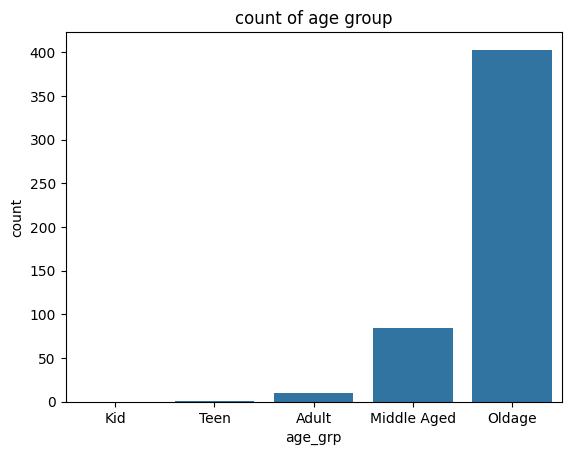

In [46]:
sns.countplot(hyp_df, x='age_grp')
plt.title('count of age group')
plt.show()

most of the people suffering from hypertension is old people

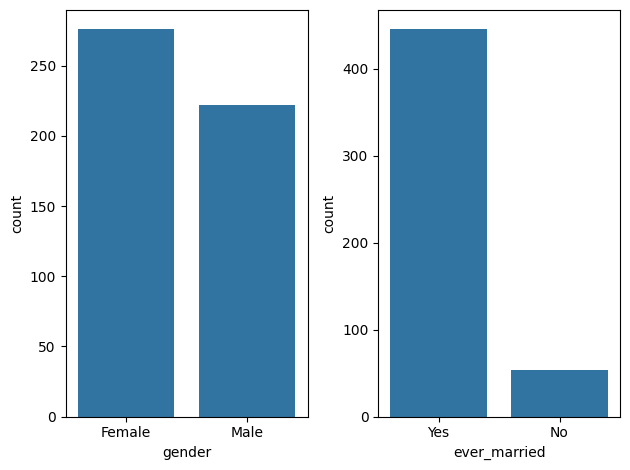

In [ ]:
f, a = plt.subplots(ncols=2)
sns.countplot(hyp_df, x='gender', ax=a[0])
sns.countplot(hyp_df, x='ever_married', ax=a[1])
plt.tight_layout()
a[0].set_title('gender count having hypertension')
a[1].set_title('married count having hypertension')
plt.show()

people who are suffering from hypertension is mostly married and majority of the patients are females

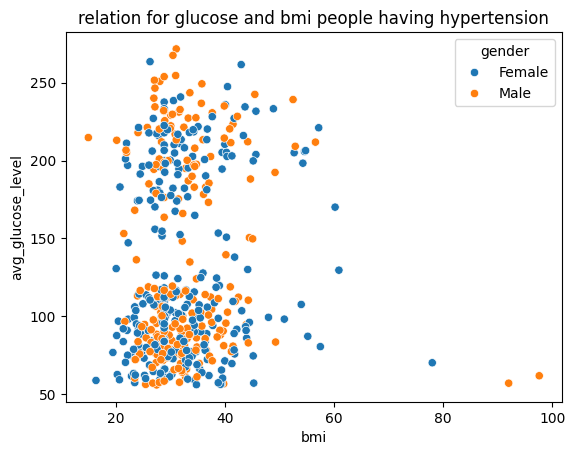

In [47]:
sns.scatterplot(hyp_df, x='bmi', y='avg_glucose_level', hue='gender')
plt.title('relation for glucose and bmi people having hypertension')
plt.show()

people who are having hypertension is having moderate bmi value where most of them has bmi in tthe range of 25-40,
 however the avg glucose level is acting like 2 groups, where one group is in range of 127-67 and the other group from 170-250 in this second group the bmi value of individuals is not as close as the first group, indicating a higher value of bmi avg

HEART DISEASE

In [30]:
heart_df = df.loc[df['heart_disease']==1]

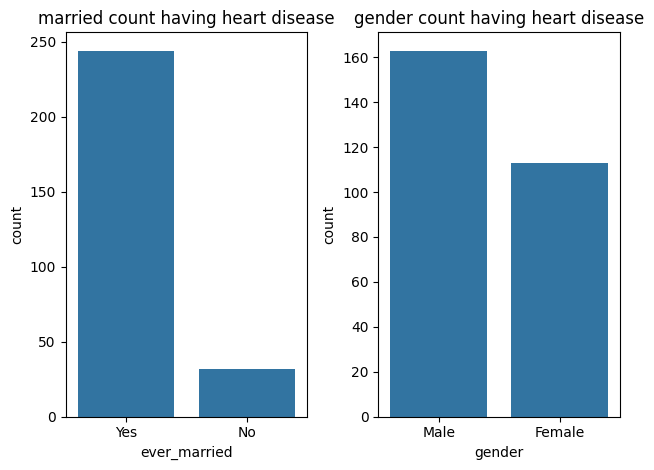

In [49]:
f, a = plt.subplots(ncols=2)
sns.countplot(heart_df, x='ever_married', ax=a[0])
sns.countplot(heart_df, x='gender', ax=a[1])
a[1].set_title('gender count having heart disease')
a[0].set_title('married count having heart disease')
plt.tight_layout()
plt.show()

majority of the people who are having heart disease are males(160+) and majority of these people are married (~250)

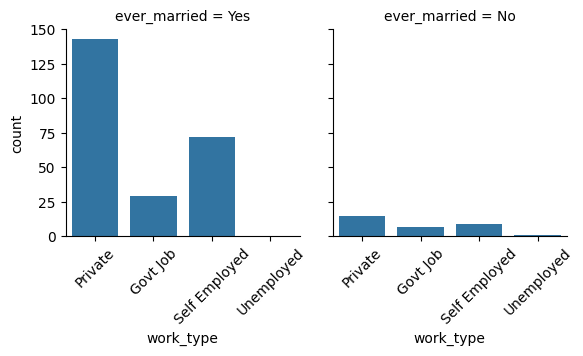

In [32]:
fg = sns.FacetGrid(heart_df, col='ever_married')
fg.map(sns.countplot, 'work_type')
for ax in fg.axes.flat:
    for l in ax.get_xticklabels():
        l.set_rotation(45)

majority of the people suffering from heart disease are people who are married, in that people who are having private job has more chance of having heart disease, 

this directly points that married people are having more disease

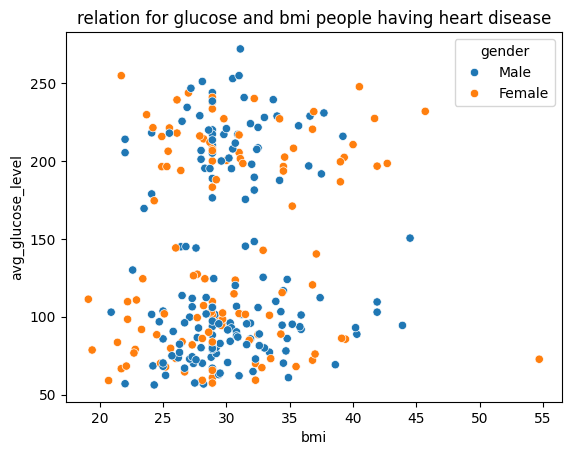

In [50]:
sns.scatterplot(heart_df, x='bmi', y='avg_glucose_level', hue='gender')
plt.title('relation for glucose and bmi people having heart disease')
plt.show()

the bmi value is scattered for people having heart disease in a range of 20 to 43, however similar to the hypertension data avg glucose level is forming 2 groups , here in both group data is scattered  wide

STROKE

In [34]:
stroke_df = df.loc[df['stroke']==1]

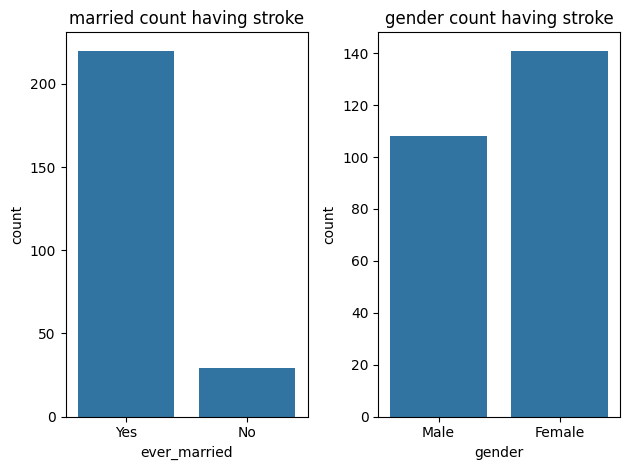

In [52]:
f, a = plt.subplots(ncols=2)
sns.countplot(stroke_df, x='ever_married', ax=a[0])
sns.countplot(stroke_df, x='gender', ax=a[1])
a[1].set_title('gender count having stroke')
a[0].set_title('married count having stroke')
plt.tight_layout()
plt.show()

majority of the people who had sroke is from females with almost 140, and over 200 of the people who had stoke are married people

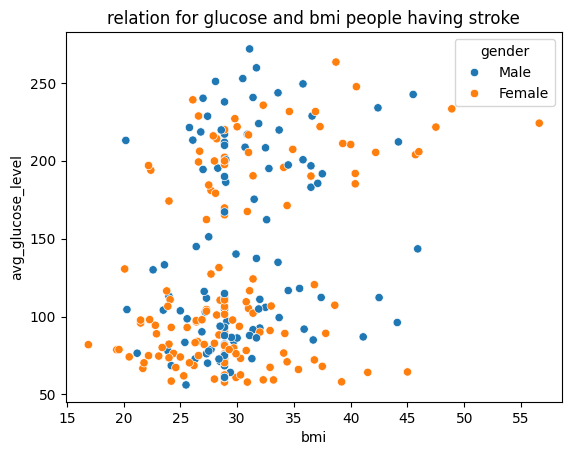

In [53]:
sns.scatterplot(stroke_df, x='bmi', y='avg_glucose_level', hue='gender')
plt.title('relation for glucose and bmi people having stroke')
plt.show()

bmi of people having stroke is more closer with avg glucose level below 150 above tha glucose range bmi of people are more scattered, the second cluster from range 250-180, in the second cluster bmi values are more scattered 

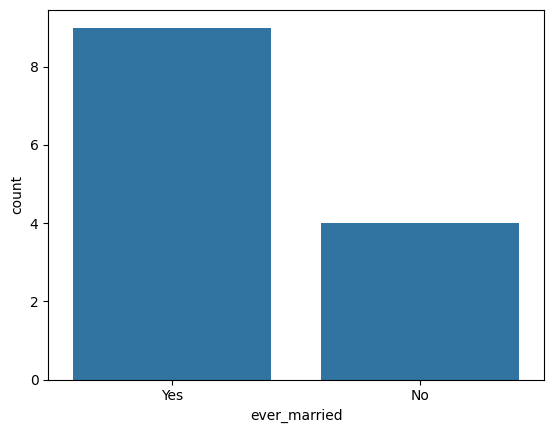

In [54]:
stroke_n_hyp = hyp_df.loc[hyp_df['stroke'] == 1]
all_df = stroke_n_hyp.loc[stroke_n_hyp['heart_disease'] == 1]
sns.countplot(all_df, x='ever_married')
plt.show()

people having all 3 issues are mostly married showing almsot 100% more people are married 

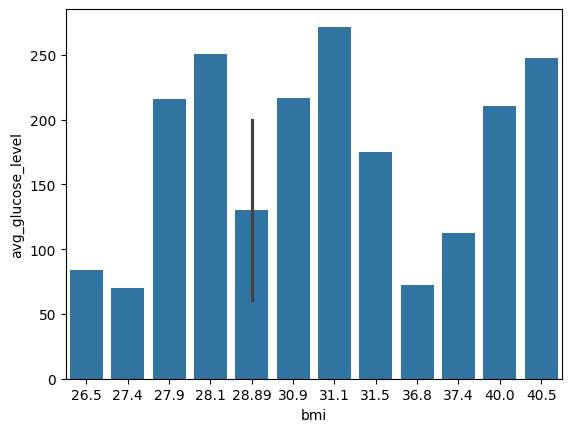

In [38]:
sns.barplot(all_df, x='bmi', y='avg_glucose_level')
plt.show()

peopel are having bmi in the normal, but a few of them are obese, range but for the glucose level most of them are diabetic

OVERALL OBSERVATION

age is the most important factor deciding health, people are in their oldage

over 54% of the people in this dataset are females and most of the people are working in private sector, also a minor edge for people who are living in rural area

the fact that people are married actually affects the health of people, most of the people having any of the 3 health issue is married 

the factor of gender, age and job is naturally affected in every diseases

people having hypertension will have normal range of bmi while glucose forms 2 clusters where the second cluster is above avg level, this trend is followed in every other disease

for people having stroke the mjority of people having stroke is self-employed

for stroke people having glucose level above avg is also having a bit abnormal of bmi value indicating obese and diabteic people are more likley to have stroke